# Programming in Python II - Final Coding Project

Author:Xhesika Gjyla

Student ID:K12539281   

Save this file under a file name in the format k+matriculation_number.ipynb, e.g. *k1234567.ipynb*. Remember that for final submission all code cells must run without errors and all cells have to be evaluated.

The code cells are a basic scaffold - you can of course add new code cells if necessary. However, stick to the overall structure of the template to facilitate grading. Ensure to comment your code and structure it reasonably.

In [62]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [63]:
# checking successful setup
print(f"Using device: {device}")

Using device: cpu


In [64]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [65]:
# Set working directory to the project folder
import os
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\User\Desktop\MSC AI JKU\SEM 2\Python 2\k12539281_final_project


In [66]:
# creating folder 'assets' if necessary
os.makedirs("assets", exist_ok=True)

## Data Handling and Pre-Processing

In [67]:
# your code goes here (preprocess function)
import os
import pandas as pd

def preprocess(data_folder: str) -> tuple[pd.DataFrame, dict]:
        
    label_dict = {
        0: "HerbaceousVegetation",
        1: "AnnualCrop",
        2: "Residential",
        3: "Pasture",
        4: "Industrial",
        5: "River",
        6: "Highway",
        7: "Forest",
        8: "PermanentCrop",
        9: "SeaLake"
    }
    class_to_label = {v: k for k, v in label_dict.items()}
    rows = []

    for class_name in os.listdir(data_folder): 
        class_path = os.path.join(data_folder, class_name) 

        if os.path.isdir(class_path):
            for file_name in os.listdir(class_path):
                if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                    rows.append({  
                        "folder": class_path,
                        "file_name": file_name,
                        "label": class_to_label[class_name],
                    })
    df = pd.DataFrame(rows)
    return df, label_dict

In [68]:
# checking successful dataframe loading
df, label_dict = preprocess("Data Sets-20260526/data")
print(f"Length of dataset: {len(df)}")

Length of dataset: 10000


In [69]:
# your code goes here (splitting train/validation datasets)
from sklearn.model_selection import train_test_split
data_folder = "Data Sets-20260526/data"
df, label_dict = preprocess(data_folder)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,          
    stratify=df["label"],   
    random_state=42,        
    shuffle=True           
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

Training set size: 8000
Validation set size: 2000


## Exploratory Data Analysis (EDA)

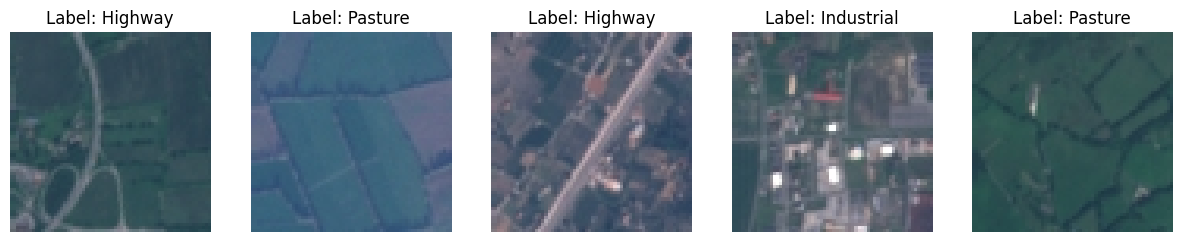

In [70]:
from PIL import Image

# your code goes here (show_samples)
def show_samples(df: pd.DataFrame, num_samples: int = 5) -> None:
    samples = df.sample(n=num_samples, random_state=36)

    os.makedirs("assets/plots", exist_ok=True)

    plt.figure(figsize=(15, 3))

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(row["folder"], row["file_name"])
        img = Image.open(img_path)

        img_folder = os.path.basename(row["folder"])

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title("Label: " + img_folder)
        plt.axis("off")

    plt.savefig("assets/plots/random_samples.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

show_samples(df, 5)

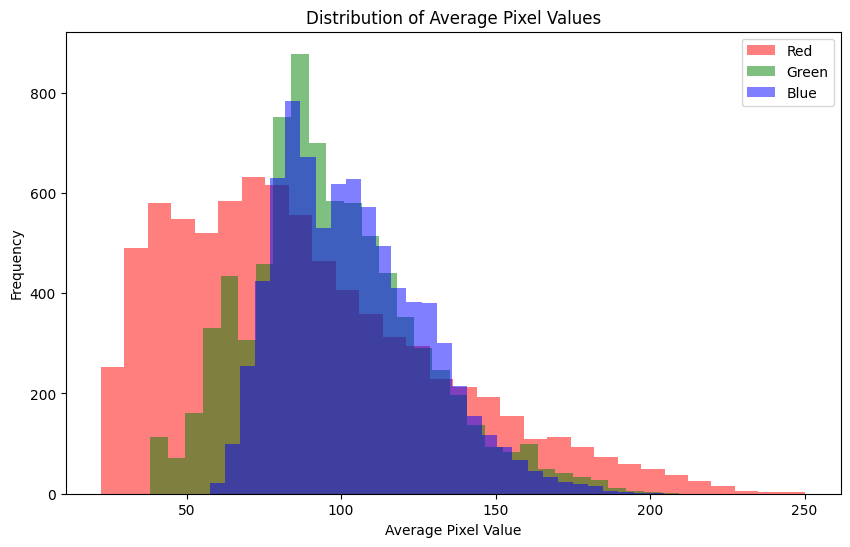

In [71]:
# your code goes here (average_pixel_plot)

def average_pixel_plot(df: pd.DataFrame) -> None:
    red_means = []
    green_means = []
    blue_means = []

    os.makedirs("assets/plots", exist_ok=True)

    for _, row in df.iterrows():
        img_path = os.path.join(row["folder"], row["file_name"])
        img = Image.open(img_path).convert("RGB")

        img_array = np.array(img)

        red_means.append(img_array[:, :, 0].mean()) 
        green_means.append(img_array[:, :, 1].mean()) 
        blue_means.append(img_array[:, :, 2].mean()) 

    plt.figure(figsize=(10, 6))

    plt.hist(red_means, bins=30, alpha=0.5, label="Red", color="Red")
    plt.hist(green_means, bins=30, alpha=0.5, label="Green", color="Green")
    plt.hist(blue_means, bins=30, alpha=0.5, label="Blue", color="Blue")

    plt.xlabel("Average Pixel Value")
    plt.ylabel("Frequency")
    plt.title("Distribution of Average Pixel Values")
    plt.legend()

    plt.savefig("assets/plots/average_pixel_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

average_pixel_plot(train_df)

C:\Users\User\AppData\Local\Temp\ipykernel_12684\3372058513.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


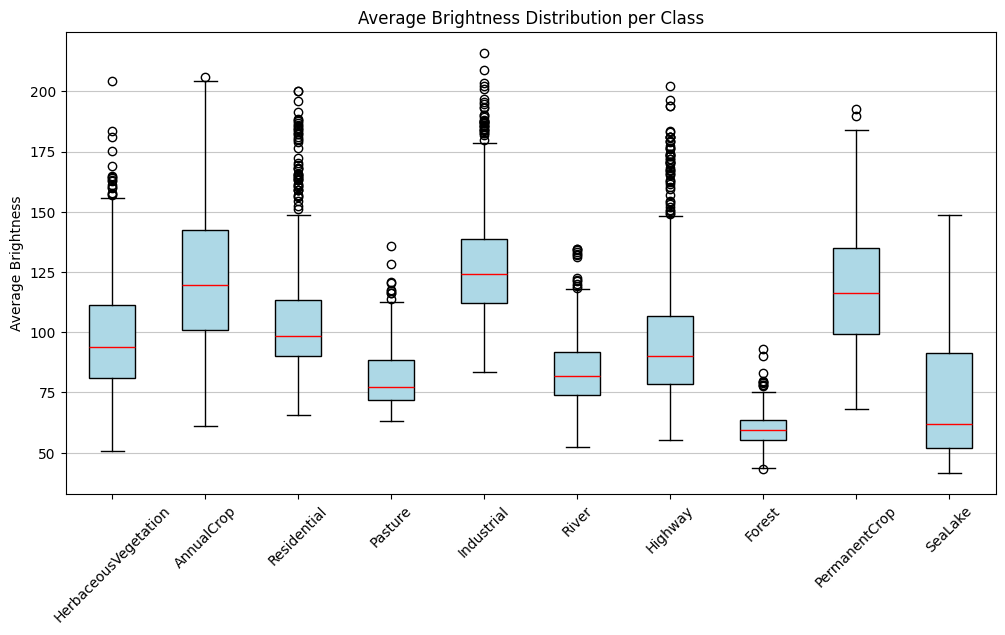

In [72]:
# your code goes here (average_brightness_per_class)

def average_brightness_per_class(df: pd.DataFrame) -> None:
    os.makedirs("assets/plots", exist_ok=True)

    brightness_per_class = []
    labels = []

    for label in sorted(df["label"].unique()):
        class_df = df[df["label"] == label]

        class_averages = []

        for _, row in class_df.iterrows():
            img_path = os.path.join(row["folder"], row["file_name"])
            img = Image.open(img_path).convert("RGB")
            img_arr = np.array(img)

            img_avg = img_arr.mean()
            class_averages.append(img_avg)

        brightness_per_class.append(class_averages)
        labels.append(label)

    plt.figure(figsize=(12, 6))
    box = plt.boxplot(
    brightness_per_class,
    labels=[label_dict[i] for i in sorted(df["label"].unique())],
    patch_artist=True
    )
    for b in box["boxes"]:
        b.set_facecolor("lightblue")
    for median in box["medians"]:
        median.set_color("red")
        median.set_linewidth(1)
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="-", alpha=0.7)
    plt.title("Average Brightness Distribution per Class")
    plt.ylabel("Average Brightness")
    plt.savefig("assets/plots/average_brightness.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

average_brightness_per_class(train_df)
    

## CNN Implementation and Training

### Dataset class

In [73]:
# your code goes here
from torch.utils.data import Dataset
from torchvision import transforms

class SatelliteDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        img_path = os.path.join(row["folder"], row["file_name"])
        image = Image.open(img_path).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label


In [74]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [75]:
train_dataset = SatelliteDataset(train_df, transform=train_transform)
val_dataset = SatelliteDataset(val_df, transform=val_transform)

### Data Loaders

In [76]:
# your code goes here
from torch.utils.data import DataLoader

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True,generator=g,num_workers=0)
val_loader = DataLoader(val_dataset,batch_size=64,shuffle=False,generator=g,num_workers=0)

### Model Architecture

In [77]:
# your code goes here
import torch
import torch.nn as nn
import torch.nn.functional as F

class SatelliteCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv_layers = nn.Sequential(
            # input: 3 x 64 x 64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 x 32 x 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 x 16 x 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128 x 8 x 8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 256 x 4 x 4
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

### Training Loop

In [78]:
# your code goes here
import torch.optim as optim

def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=30,
    learning_rate=0.001,
    patience=5,
    device=None
):
    os.makedirs("assets/weights", exist_ok=True)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_acc = 0.0
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        scheduler.step(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                "assets/weights/best_model.pth"
            )

            print("Best model saved.")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accuracies,
        "val_acc": val_accuracies
    }

    return model, history

In [79]:
model = SatelliteCNN(num_classes=10)

model.load_state_dict(torch.load("assets/weights/best_model.pth"))

model.to(device)

model, history = train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=20,
    learning_rate=0.0003,
    patience=8
)

Epoch [1/20] Train Loss: 0.0954 Train Acc: 0.9671 Val Loss: 0.2212 Val Acc: 0.9370
Best model saved.
Epoch [2/20] Train Loss: 0.1327 Train Acc: 0.9560 Val Loss: 0.1928 Val Acc: 0.9445
Best model saved.
Epoch [3/20] Train Loss: 0.1282 Train Acc: 0.9574 Val Loss: 0.2069 Val Acc: 0.9400
Epoch [4/20] Train Loss: 0.1189 Train Acc: 0.9595 Val Loss: 0.2199 Val Acc: 0.9420
Epoch [5/20] Train Loss: 0.1224 Train Acc: 0.9606 Val Loss: 0.2000 Val Acc: 0.9405
Epoch [6/20] Train Loss: 0.0954 Train Acc: 0.9666 Val Loss: 0.1927 Val Acc: 0.9445
Epoch [7/20] Train Loss: 0.0970 Train Acc: 0.9669 Val Loss: 0.1778 Val Acc: 0.9525
Best model saved.
Epoch [8/20] Train Loss: 0.0879 Train Acc: 0.9686 Val Loss: 0.1775 Val Acc: 0.9505
Epoch [9/20] Train Loss: 0.0804 Train Acc: 0.9710 Val Loss: 0.1895 Val Acc: 0.9460
Epoch [10/20] Train Loss: 0.0837 Train Acc: 0.9722 Val Loss: 0.1850 Val Acc: 0.9535
Best model saved.
Epoch [11/20] Train Loss: 0.0914 Train Acc: 0.9677 Val Loss: 0.2647 Val Acc: 0.9315
Epoch [12/20]

## Model Evaluation

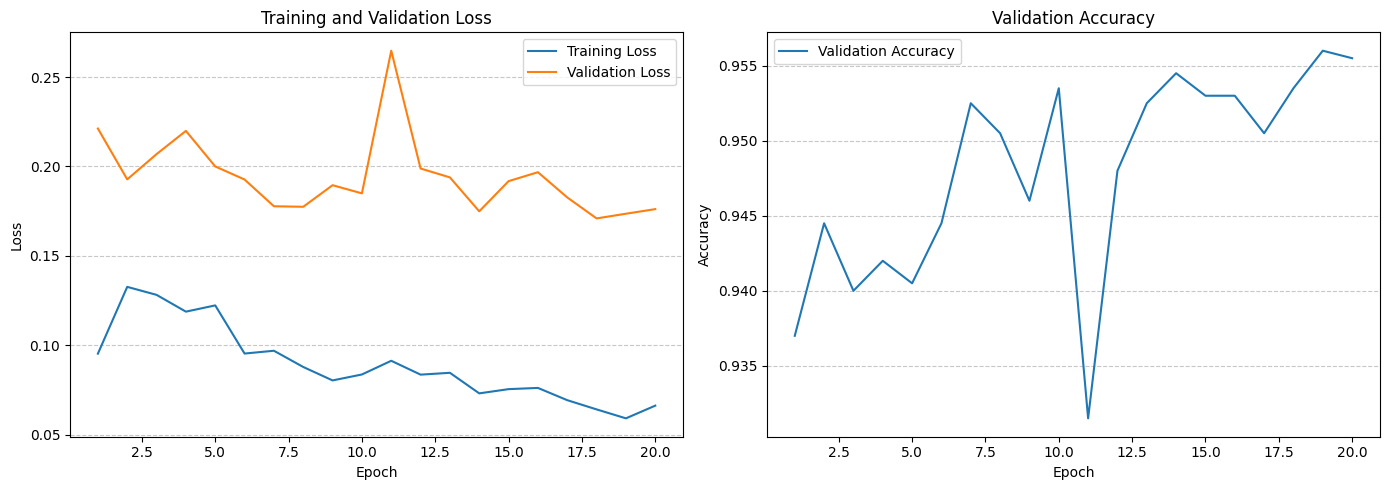

In [80]:
# your code goes here (plot_training_curves)
def plot_training_history(history):
    os.makedirs("assets/plots", exist_ok=True)

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig("assets/plots/training_history.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    
plot_training_history(history)

<Figure size 1000x800 with 0 Axes>

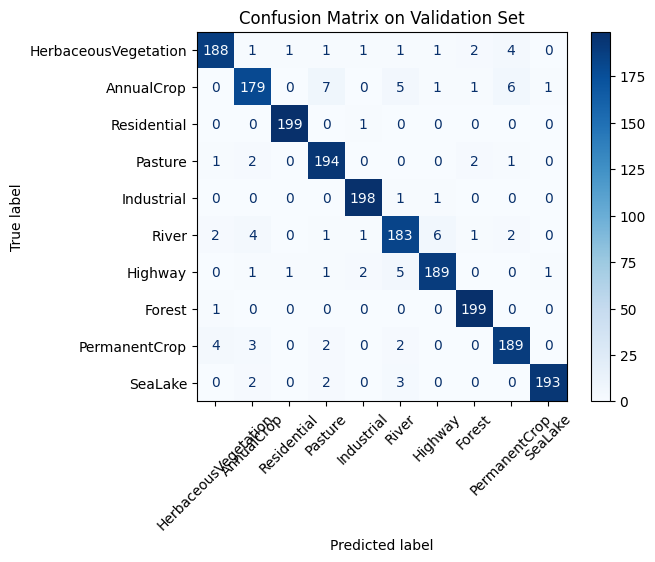

In [81]:
# your code goes here (plot_confusion_matrix)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, val_loader, label_dict, device=None):
    os.makedirs("assets/plots", exist_ok=True)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    class_names = [label_dict[i] for i in range(len(label_dict))]

    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix on Validation Set")

    plt.savefig("assets/plots/confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

plot_confusion_matrix(model, val_loader, label_dict)

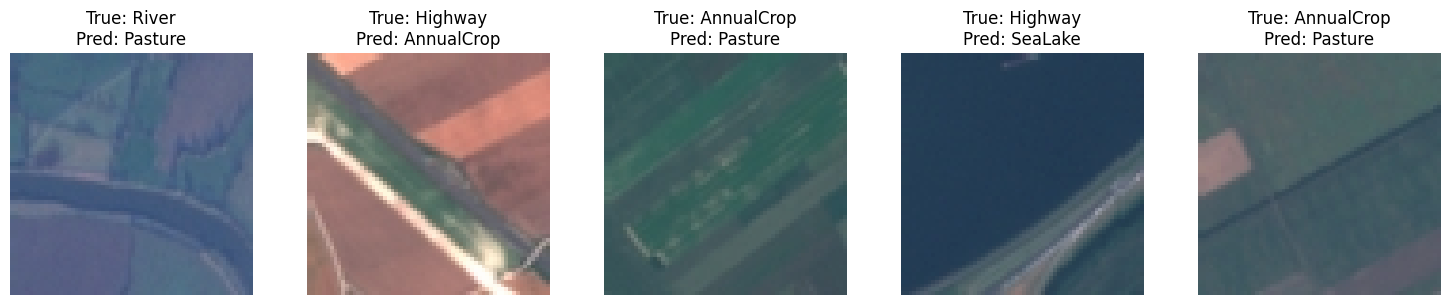

In [82]:
# your code goes here (plot_misclassified_samples)
def show_misclassified_samples(model, val_loader, label_dict, num_samples=5, device=None):
    os.makedirs("assets/plots", exist_ok=True)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    model.eval()

    misclassified_images = []
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images_device = images.to(device)
            labels_device = labels.to(device)

            outputs = model(images_device)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                if preds[i] != labels_device[i]:
                    misclassified_images.append(images[i])
                    true_labels.append(labels[i].item())
                    predicted_labels.append(preds[i].cpu().item())

                if len(misclassified_images) == num_samples:
                    break

            if len(misclassified_images) == num_samples:
                break

    plt.figure(figsize=(15, 3))

    for i in range(len(misclassified_images)):
        img = misclassified_images[i].permute(1, 2, 0).numpy()

        # undo ImageNet normalization if you used it
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)

        true_name = label_dict[true_labels[i]]
        pred_name = label_dict[predicted_labels[i]]

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"True: {true_name}\nPred: {pred_name}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig("assets/plots/misclassified_samples.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

show_misclassified_samples(model, val_loader, label_dict)

### Test Set

In [83]:
# your code goes here (preprocess_test_data)
def preprocess_test(data_folder: str) -> pd.DataFrame:
    rows = []

    for file_name in os.listdir(data_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            rows.append({
                "folder": data_folder,
                "file_name": file_name
            })

    df = pd.DataFrame(rows)

    return df

test_folder = "Data Sets-20260526/public_test_data"
test_df = preprocess_test(test_folder)
print(test_df.head())
print(len(test_df))

                                folder file_name
0  Data Sets-20260526/public_test_data  1001.jpg
1  Data Sets-20260526/public_test_data  1002.jpg
2  Data Sets-20260526/public_test_data  1008.jpg
3  Data Sets-20260526/public_test_data   101.jpg
4  Data Sets-20260526/public_test_data  1034.jpg
1980


In [84]:
# your code goes here (create dataset and dataloader)
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class SatelliteTestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        img_path = os.path.join(row["folder"], row["file_name"])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, row["file_name"]
    
test_dataset = SatelliteTestDataset(test_df, transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [85]:
# your code goes here (evaluate model on test set)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SatelliteCNN(num_classes=10)
model.load_state_dict(torch.load("assets/weights/best_model.pth", map_location=device))
model.to(device)
model.eval()

test_predictions = []

with torch.no_grad():
    for images, file_names in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for file_name, pred in zip(file_names, preds):
            class_name = label_dict[pred.item()]
            test_predictions.append((file_name, class_name))

test_predictions[:10]

[('1001.jpg', 'HerbaceousVegetation'),
 ('1002.jpg', 'Residential'),
 ('1008.jpg', 'HerbaceousVegetation'),
 ('101.jpg', 'Highway'),
 ('1034.jpg', 'HerbaceousVegetation'),
 ('1042.jpg', 'AnnualCrop'),
 ('1046.jpg', 'PermanentCrop'),
 ('1049.jpg', 'AnnualCrop'),
 ('1056.jpg', 'PermanentCrop'),
 ('1066.jpg', 'Pasture')]

In [86]:
# your code goes here (create submission csv file for challenge server)
import csv

with open("submission.csv", mode="w", newline="") as file:
    writer = csv.writer(file)

    for file_name, class_name in test_predictions:
        writer.writerow([file_name, class_name])


with open("submission.csv", "r") as file:
    for _ in range(10):
        print(file.readline().strip())

1001.jpg,HerbaceousVegetation
1002.jpg,Residential
1008.jpg,HerbaceousVegetation
101.jpg,Highway
1034.jpg,HerbaceousVegetation
1042.jpg,AnnualCrop
1046.jpg,PermanentCrop
1049.jpg,AnnualCrop
1056.jpg,PermanentCrop
1066.jpg,Pasture
